In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/book-recommendation-dataset/Ratings.csv
/kaggle/input/book-recommendation-dataset/Users.csv
/kaggle/input/book-recommendation-dataset/classicRec.png
/kaggle/input/book-recommendation-dataset/Books.csv
/kaggle/input/book-recommendation-dataset/DeepRec.png
/kaggle/input/book-recommendation-dataset/recsys_taxonomy2.png


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
users_df = pd.read_csv("/kaggle/input/book-recommendation-dataset/Users.csv")
books_df = pd.read_csv("/kaggle/input/book-recommendation-dataset/Books.csv", low_memory=False)
ratings_df = pd.read_csv("/kaggle/input/book-recommendation-dataset/Ratings.csv")

In [4]:
users_df.shape

(278858, 3)

In [5]:
books_df.shape

(271360, 8)

In [6]:
ratings_df.shape

(1149780, 3)

# Explatory Data Analysis

In [7]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


for simplicity, only keep the country at location

In [8]:
users_df['Location'] = users_df['Location'].str.split(',').str[-1].str.strip()

In [9]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


i think the image of medium size would be sufficent

In [10]:
books_df = books_df.drop(['Image-URL-S', 'Image-URL-L'], axis=1)
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-M
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...


In [11]:
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [12]:
 ratings_df['Book-Rating'].max() - ratings_df['Book-Rating'].min()

10

In [13]:
# check if there is users with zero ratings across all books
user_ratings_count = ratings_df.groupby('User-ID')['Book-Rating'].count()
no_ratings = user_ratings_count[user_ratings_count == 0].index
print("Users with no ratings:", list(no_ratings) if len(no_ratings) else "None")

Users with no ratings: None


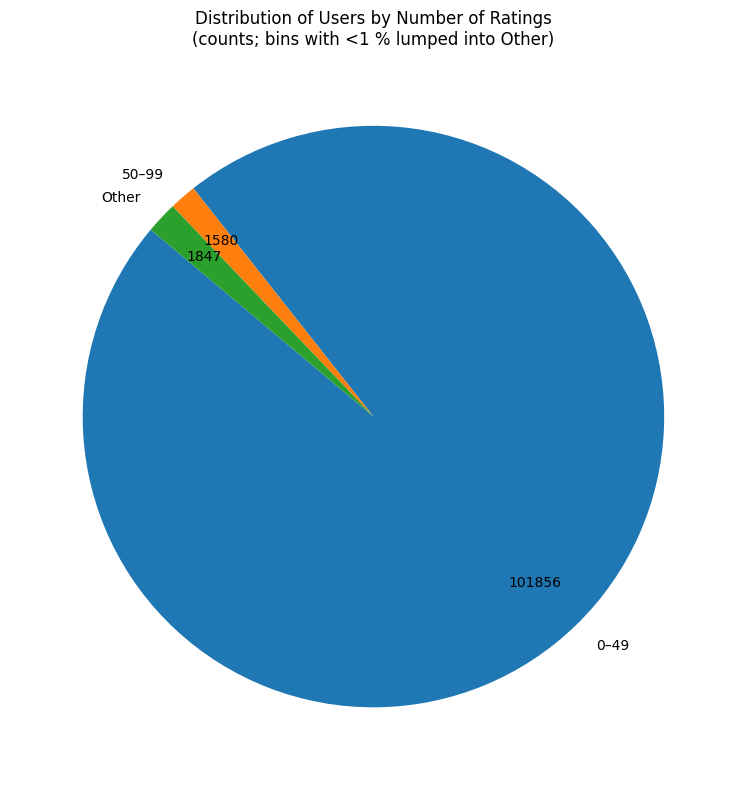

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

user_counts = ratings_df.groupby('User-ID')['Book-Rating'].count()

bin_size = 50
max_count = user_counts.max()
bins = list(range(0, max_count + bin_size, bin_size))

binned  = pd.cut(user_counts,
                    bins=bins,
                    right=False,
                    include_lowest=True)
user_counts_binned = binned.value_counts().sort_index()

total_users = user_counts_binned.sum()
big = user_counts_binned[user_counts_binned / total_users >= 0.01]
small = user_counts_binned[user_counts_binned / total_users <  0.01].sum()

sizes = list(big.values) + [small]
labels = [f"{int(iv.left)}–{int(iv.right)-1}" for iv in big.index] + ['Other']

def fmt_count(pct):
    return str(int(round(pct * total_users / 100)))

plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=labels,
    autopct=fmt_count,
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1
)
plt.title(
    'Distribution of Users by Number of Ratings\n' +
    '(counts; bins with <1 % lumped into Other)'
)
plt.tight_layout()
plt.show()


so most of the users has less than 50 ratings.

based on such a fact, which algorithm is not recommended?

**User-based CF will struggle** (most users don’t have enough ratings to find reliable “neighbors”).

we can try item-item CF, but let'us check ratings/book

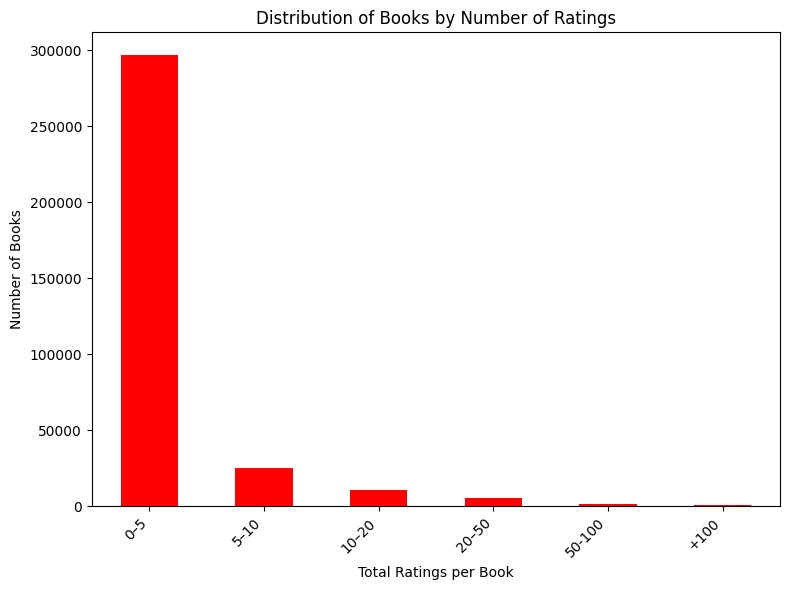

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

rating_counts = ratings_df.groupby('ISBN')['Book-Rating'].count()

bins  = [0, 5, 10, 20, 50, 100, rating_counts.max() + 1]
labels = ['0–5', '5–10', '10–20', '20–50', '50-100', '+100']

binned = pd.cut(rating_counts, bins=bins, labels=labels, right=False)
bin_counts = binned.value_counts().sort_index()

plt.figure(figsize=(8,6))
bin_counts.plot(kind='bar', color = 'red')
plt.xlabel('Total Ratings per Book')
plt.ylabel('Number of Books')
plt.title('Distribution of Books by Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

also item-item CF would not be optimum choice, we can try ALS as a baseline

In [16]:
books_df.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-M            0
dtype: int64

we can get NaN from the internet.

In [17]:
books_df[books_df.isna().any(axis=1)]
CHECK = books_df[books_df.isna().any(axis=1)] # save for later check

webscrap NaN

In [18]:
import requests
import numpy as np

def fetch_from_google(isbn):
    url    = "https://www.googleapis.com/books/v1/volumes"
    params = {"q": f"isbn:{isbn}"}
    r      = requests.get(url, params=params)
    if r.status_code != 200:
        return None, None, None

    data = r.json().get("items")
    if not data:
        return None, None, None

    info = data[0]["volumeInfo"]
    # join multiple authors if necessary
    author     = ", ".join(info.get("authors", [])) or None
    publisher  = info.get("publisher")
    # publishedDate can be "1999-05-10" or just "1999"
    year       = info.get("publishedDate", "")[:4] or None
    return author, publisher, year

# apply only to rows with ANY missing field
for idx, row in books_df[books_df[["Book-Author","Publisher","Year-Of-Publication"]]
                         .isna().any(axis=1)].iterrows():
    isbn = row["ISBN"]
    a, p, y = fetch_from_google(isbn)
    if a: books_df.at[idx, "Book-Author"] = a
    if p: books_df.at[idx, "Publisher"] = p
    if y: books_df.at[idx, "Year-Of-Publication"] = y
CHECK.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-M
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...


In [19]:
# CHECK FOR MISSING VALUES

books_df[books_df[["Book-Author","Publisher","Year-Of-Publication"]].isna().any(axis=1)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-M


In [20]:
users_df.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [21]:
ratings_df.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

now our data is clean and ready

# Modelling

will store our sparse ratings to compressed sparse row to dec computational cost, and use als matrix factorization, which can deal with sparse datasets

In [22]:
pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [23]:
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType, FloatType

In [24]:
spark = SparkSession.builder \
    .appName("ExplicitALS") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/31 16:11:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## train/test split

In [25]:
ratings_df = ratings_df.dropna(subset=["User-ID", "ISBN", "Book-Rating"]) # Drop nan BEFORE factorizing

ratings_df['isbn_code'], _ = pd.factorize(ratings_df['ISBN'])
ratings_df['User-ID'], _ = pd.factorize(ratings_df['User-ID'])
ratings_df = ratings_df[["User-ID", "isbn_code", "Book-Rating"]]

ratings_df['Book-Rating'] = ratings_df['Book-Rating'].astype(float)
ratings_df['User-ID'] = ratings_df['User-ID'].astype(int)
ratings_df['isbn_code'] = ratings_df['isbn_code'].astype(int)

In [26]:
columns = ["User-ID", "isbn_code", "Book-Rating"]
df = spark.createDataFrame(ratings_df.sample(n=10000), schema=columns)

df = df \
    .withColumn("User-ID", col("User-ID").cast(IntegerType())) \
    .withColumn("isbn_code", col("isbn_code").cast(IntegerType())) \
    .withColumn("Book-Rating", col("Book-Rating").cast(FloatType()))

In [27]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

user id is columns, ISBN is rows, rating is the cell value

### training

In [28]:
als = ALS(
    userCol="User-ID",
    itemCol="isbn_code",
    ratingCol="Book-Rating",
    rank=35,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",  # avoids NaNs
    nonnegative=True           # ratings must be positive
)
model = als.fit(train)

## evaluate

In [29]:
predictions = model.transform(test)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="Book-Rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"Root-mean-square error = {rmse:.4f}")

Root-mean-square error = 4.3744


# Conclusion
- Apach Spark was much easier for the pipeline
- Our classical model deviates ~4 ratings from 10 (which is not optimum)
- ML Engineer should be able to deal mainly with sparse datasets

## TODOs:
- use deep recommendation system algorithms (ex. NeuCF) also to add the other features like age
- embed images to n-dim space

P.S.: i tuned the hyperparameters manually till converge to this solution